<a href="https://colab.research.google.com/github/ayigirinandini/Data-Analysis-With-Python/blob/main/CLT_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

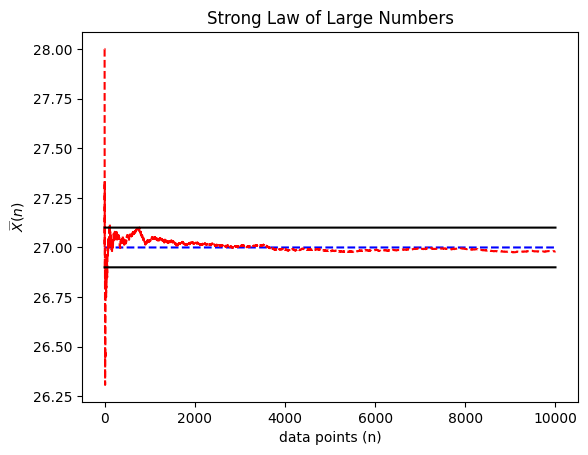

In [7]:
#Strong Law of Lagre numbers example
import numpy as np
import matplotlib.pyplot as plt

trials = 30 #binomiam trials
p = 0.9 #probability of event

num_points = 10000 # sample size

rng = np.random.default_rng()

#create binomial samples
X = rng.binomial(trials, p, num_points)
partial_sum = X.cumsum()
i_list = [i for i in range(1,num_points+1)]
partial_mean = []
for i in range(1,num_points +1):
  partial_mean = partial_mean + [partial_sum[i-1]/i]

plt.figure()
plt.plot(i_list, trials*p*np.ones(num_points), '--b')
plt.plot(i_list, partial_mean,'--r')
plt.plot(i_list, trials*p*np.ones(num_points)+0.1, 'k')
plt.plot(i_list, trials*p*np.ones(num_points)-0.1, 'k')
plt.xlabel('data points (n)')
plt.ylabel(r'$\widebar{X}(n)$')
plt.title('Strong Law of Large Numbers')
plt.show()




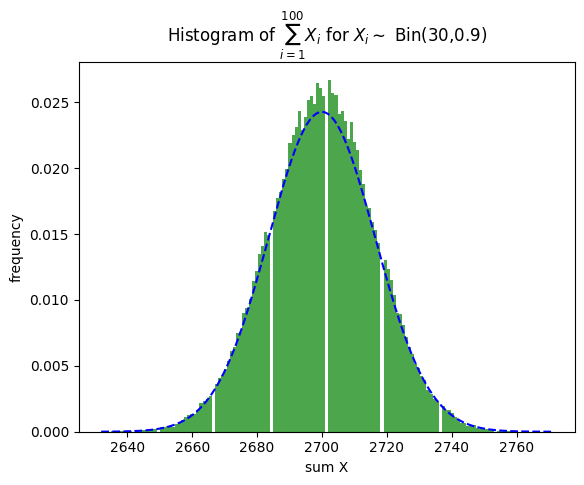

If we stock 849 bottles, then the normally distributed demand gives us
the stockout probability = 1.0
On the other hand, the actual distribution of October demand gives us
the stockout probaility approximately equal to 1.0
which is smaller than 1%. So we are fine with using the normal approximation.


In [10]:
#CLT(central limit theorem)
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb
from scipy.stats import norm
from scipy.stats import binom


trials = 30 #number of trials for binomial parameter
p = 0.9     #Prob of success- binomial parameter
sum_size = 100  #"n" num of rows in output sample array
num_points = 100000 #"m" num of rows in output sample array

X = np.random.binomial(trials, p, (sum_size, num_points)) #generate a (sum_size by num_points) matrix of binomial rvs
X = X.sum(0)  #take sum of each column (i.e., add 'sum_size' number of elements)
#print(X)
X_sum_mean = sum_size*trials*p #E[sum X] = sum_size * E[X] = sum_size * np
X_sum_var = sum_size*trials*p*(1-p) #Var(sum X) = sum_size * var(X) = sum_size * npq

plt.figure()
#binBoundaries = np.linspace(0.5, sum_size*trials+0.5, sum_size*trials+1) #end points of bins are 0.5, 1.5, ... , 30.5
count, bins, patches = plt.hist(X, bins = 'auto', density = 1, color='green', alpha=0.7)
z = norm.pdf(bins,X_sum_mean, np.sqrt(X_sum_var)) #normal pdf with mean and std
plt.plot(bins, z, '--', color='blue') #normal pdf is in a blue dashed line
plt.xlabel('sum X')
plt.ylabel('frequency')
plt.title(r'Histogram of $\sum_{i=1}^{%g} X_i$ for $X_i \sim$ Bin(30,0.9)' %sum_size)
plt.show()

#For the example on monthly demands for water bottles,
X_indicator = np.where(X>849,1,0)
print("If we stock 849 bottles, then the normally distributed demand gives us")
print("the stockout probability =", 1-norm.cdf(849,X_sum_mean,np.sqrt(X_sum_var)))
print("On the other hand, the actual distribution of October demand gives us")
print("the stockout probaility approximately equal to", np.mean(X_indicator))
print("which is smaller than 1%. So we are fine with using the normal approximation.")

